# Chapter 06 — Structure and Analysis: RDF, MSD/diffusion, VACF and S(k) from a dump, with block-average error bars

*lammps-skill 0.1.10. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter06_structure_analysis.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)
7. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

lammps-skill 0.1.10 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## From a dump to five numbers

Everything in this chapter reads one trajectory -- an LJ melt, dumped every 20 steps with
unwrapped positions and velocities -- through `lammpskill.post`: the radial distribution function
`g(r)`, the structure factor `S(k)` computed from it, the mean-squared displacement and the
diffusion coefficient it implies, the velocity autocorrelation function, and a block-average error
bar on the temperature. The record this chapter writes keeps only these derived numbers, not the
trajectory itself -- the same discipline as any other record in this project (`data/records/` holds
small, checkable summaries, never raw simulation output).

## Making the trajectory and reducing it, in one `compute()`

The dump uses `xu yu zu` (already unwrapped by LAMMPS, so `lammpskill.post.msd` needs no
reconstruction) and `vx vy vz` for the velocity autocorrelation. 864 atoms, 2000 steps, a dump every
20 steps -- 101 frames. The analysis runs once, inside `compute()`, while the trajectory still
exists on disk in a temporary directory; only the reduced arrays below leave that function.

In [2]:
import os
import tempfile

import numpy as np

from lammpskill.io.dump import read_dump
from lammpskill.post import block_average, diffusion_coefficient, msd, rdf_trajectory, structure_factor, vacf
from lammpskill.run import run, run_or_load
from lammpskill.script import Spec, Stage

DT = 0.005
DUMP_EVERY = 20

traj_spec = Spec(
    units="lj", atom_style="atomic", lattice="fcc 0.8442", region="box block 0 6 0 6 0 6",
    create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
    neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
    velocity=["all create 3.0 87287 loop geom"], timestep=DT, fixes=["1 all nve"],
    dumps=["1 all custom %d traj.dump id type xu yu zu vx vy vz" % DUMP_EVERY],
    thermo=100, thermo_style="custom step temp epair etotal press",
    stages=[Stage("run", "2000")], comment="LJ melt with a trajectory dump for chapter 06's analysis",
)


def compute():
    workdir = tempfile.mkdtemp(prefix="ch06_traj_")
    result = run(traj_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("trajectory run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    traj = read_dump(os.path.join(workdir, "traj.dump"))
    natoms, nframes = traj.frames[0].natoms, len(traj)

    # g(r) and S(k): the second half only -- the first half is the hot lattice still disordering.
    from lammpskill.io.dump import Trajectory
    eq = Trajectory(traj.frames[nframes // 2:])
    r, g = rdf_trajectory(eq, nbins=80)
    k, S = structure_factor(r, g, rho=natoms / eq.box.volume)

    # MSD / diffusion: xu/yu/zu are already unwrapped.
    t, m = msd(traj, dt=DT * DUMP_EVERY, unwrap=False)
    D, D_err = diffusion_coefficient(t, m)

    # VACF over the first 30 lags.
    vel = np.stack([np.column_stack([f.get("vx"), f.get("vy"), f.get("vz")]) for f in traj.frames])
    lag, c = vacf(vel, dt=DT * DUMP_EVERY, max_lag=30)

    T_mean, T_err = block_average(result.thermo.get("Temp"), nblocks=7)

    return {
        "natoms": natoms, "nframes": nframes, "dt": DT, "dump_every": DUMP_EVERY,
        "route": result.installation.route if result.installation else None,
        "rdf_r": r.tolist(), "rdf_g": g.tolist(), "sk_k": k.tolist(), "sk_S": S.tolist(),
        "msd_t": t.tolist(), "msd_m": m.tolist(), "D": D, "D_err": D_err,
        "vacf_lag": lag.tolist(), "vacf_c": c.tolist(), "T_mean": T_mean, "T_err": T_err,
    }


rec = run_or_load("lj_structure_ch06", compute, records_dir="../data/records")
print("source:", rec["source"], "| natoms:", rec.get("natoms"), "| frames:", rec.get("nframes"))

source: record | natoms: 864 | frames: 101


## Radial distribution function and structure factor

`g(r)` measures structure in real space -- a liquid's first peak near the particle diameter,
decaying to 1 (the ideal-gas value) at large `r`. `S(k)` is the same information in reciprocal
space, computed *from* `g(r)`, not measured independently.

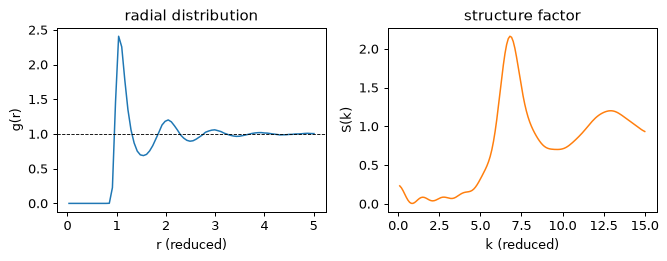

g(r) first peak: r=1.039, g=2.41


In [3]:
import matplotlib.pyplot as plt

if rec["source"] != "skip":
    r, g, k, S = rec["rdf_r"], rec["rdf_g"], rec["sk_k"], rec["sk_S"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3), dpi=90)
    ax1.plot(r, g, lw=1.2); ax1.axhline(1.0, color="k", ls="--", lw=0.7)
    ax1.set_xlabel("r (reduced)"); ax1.set_ylabel("g(r)"); ax1.set_title("radial distribution")
    ax2.plot(k, S, lw=1.2, color="tab:orange")
    ax2.set_xlabel("k (reduced)"); ax2.set_ylabel("S(k)"); ax2.set_title("structure factor")
    fig.tight_layout()
    plt.show()
    imax = int(np.argmax(g))
    print("g(r) first peak: r=%.3f, g=%.2f" % (r[imax], g[imax]))
else:
    print("no LAMMPS and no record: nothing to analyse")

## Mean-squared displacement and the diffusion coefficient

The diffusion coefficient is a linear fit to the *later* part of MSD(t), where the motion is
genuinely diffusive rather than still ballistic (`lammpskill.post.diffusion_coefficient` fits from
the second half by default).

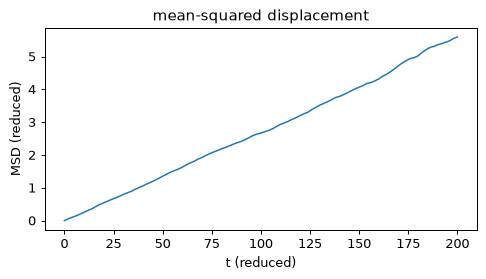

D = 0.0050 +/- 0.0000 (reduced units, Einstein relation, fit over the second half)


In [4]:
if rec["source"] != "skip":
    fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=90)
    ax.plot(rec["msd_t"], rec["msd_m"], lw=1.2)
    ax.set_xlabel("t (reduced)"); ax.set_ylabel("MSD (reduced)"); ax.set_title("mean-squared displacement")
    fig.tight_layout()
    plt.show()
    print("D = %.4f +/- %.4f (reduced units, Einstein relation, fit over the second half)" % (rec["D"], rec["D_err"]))

## Velocity autocorrelation

`vacf` normalises to 1 at zero lag; a liquid's VACF decays roughly monotonically, a solid's
oscillates (the atoms are caught in a cage). Which one this trajectory shows is itself a check that
the case really did melt.

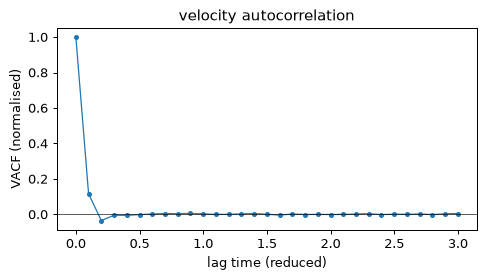

VACF at lag 0: 1.0 (must be 1 by construction)


In [5]:
if rec["source"] != "skip":
    fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=90)
    ax.plot(rec["vacf_lag"], rec["vacf_c"], marker="o", ms=3, lw=1.0)
    ax.axhline(0.0, color="k", lw=0.5)
    ax.set_xlabel("lag time (reduced)"); ax.set_ylabel("VACF (normalised)"); ax.set_title("velocity autocorrelation")
    fig.tight_layout()
    plt.show()
    print("VACF at lag 0:", rec["vacf_c"][0], "(must be 1 by construction)")

## Block-average error bars

A single mean over a correlated time series understates its own uncertainty. `block_average`
splits the series into blocks, averages within each, then takes the standard error *across
blocks* -- correlated samples inside a block do not inflate the apparent precision.

In [6]:
if rec["source"] != "skip":
    print("temperature over the run: %.3f +/- %.3f (block-averaged, 7 blocks)" % (rec["T_mean"], rec["T_err"]))

temperature over the run: 1.704 +/- 0.068 (block-averaged, 7 blocks)


## Reading it

- `g(r)`, `S(k)`, MSD/`D` and VACF are four views of the same trajectory, not four independent
  measurements -- `S(k)` is literally computed from `g(r)`, and a VACF that does not decay would
  make the diffusion coefficient from MSD suspect for the same reason.
- Diffusive vs ballistic motion is a *regime*, not a property of the whole trajectory: fitting `D`
  from the early, still-ballistic part of MSD(t) is a common way to get a confidently wrong number,
  which is why the fit here uses only the later half.
- The record this chapter writes holds the reduced arrays above, not the trajectory that produced
  them -- 864 atoms x 101 frames of positions and velocities would be several megabytes of committed
  JSON for no benefit a plot doesn't already give a reader.

In [7]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('run_or_load returned one of its three documented outcomes', bool(rec['source'] in ('run', 'record', 'skip'))))
checks.append(('the VACF is normalised to 1 at zero lag, by construction', bool(rec['source'] == 'skip' or rec['vacf_c'][0] == 1.0)))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 06: a claim above is not true'
print('chapter 06: %d claim(s) checked' % len(checks))

PASS

 run_or_load returned one of its three documented outcomes
PASS the VACF is normalised to 1 at zero lag, by construction
chapter 06: 2 claim(s) checked
